In [1]:
#Example of supress warnings for Numpy version out of range (optional)
import warnings
warnings.filterwarnings("ignore", category=Warning)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Some recommended libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import zipfile
import requests
from io import BytesIO
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

In [48]:
# load in data
df = pd.DataFrame()
subject_ids = [2301, 2304, 2307, 2308, 2309]
for subject in subject_ids:
    sub_df = pd.read_csv(f"scaledData/{subject}.csv")
    sub_df["id"] = [subject] * len(sub_df["value"])
    df = pd.concat([df, sub_df])
    
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6723 entries, 0 to 1674
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   intensity              6723 non-null   float64
 1   value                  6723 non-null   float64
 2   carbs_g                6723 non-null   float64
 3   prot_g                 6723 non-null   float64
 4   fat_g                  6723 non-null   float64
 5   bolus_dose             6723 non-null   float64
 6   basal_dose             6723 non-null   float64
 7   is_asleep              6723 non-null   bool   
 8   time_of_day_Afternoon  6723 non-null   bool   
 9   time_of_day_Evening    6723 non-null   bool   
 10  time_of_day_Morning    6723 non-null   bool   
 11  time_of_day_Night      6723 non-null   bool   
 12  id                     6723 non-null   int64  
dtypes: bool(5), float64(7), int64(1)
memory usage: 505.5 KB


In [49]:
target = df["value"]
df.drop(columns=["value", "basal_dose"], inplace=True)
df.head()

,intensity,carbs_g,prot_g,fat_g,bolus_dose,is_asleep,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,id
0,0.221424,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True,2301
1,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True,2301
2,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True,2301
3,-0.897371,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True,2301
4,0.221424,-0.282536,-0.281262,-0.294808,-0.386919,False,False,False,False,True,2301


In [50]:
# split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

In [51]:
#Initialize a Linear Regression model object and train (or fit) the data
model = LinearRegression(fit_intercept=False, n_jobs = 1)
model.fit(X_train, y_train)

#Make predictions on the testing set
y_hat = model.predict(X_test)

Mean Squared Error: 0.8836217080850475
Mean Absolute Error: 0.7381307840604522
Root Mean Squared Error: 0.9400115467828294
R-squared: 0.11410589488180967


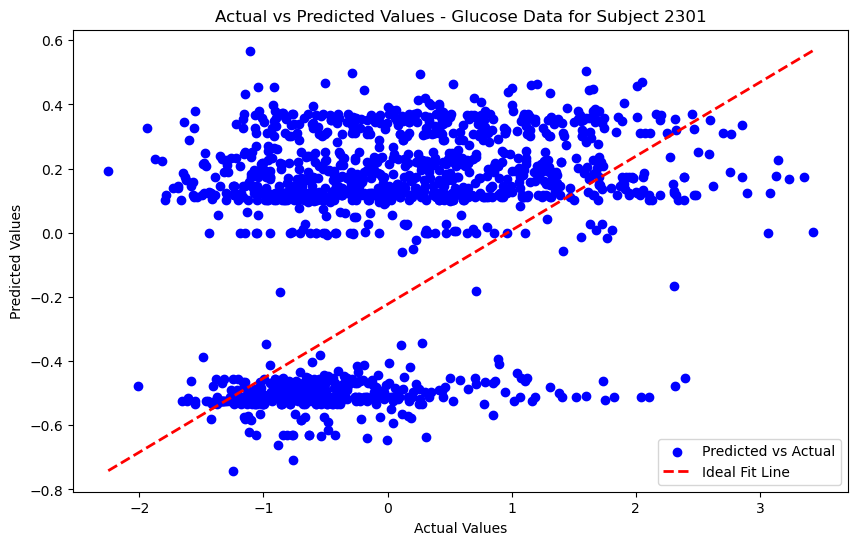

In [52]:
# Evaluate the model
mse = mean_squared_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_hat)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {np.sqrt(mse)}")
print(f"R-squared: {r2}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_hat, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_hat.min(), y_hat.max()], 'r--', lw=2, label='Ideal Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted Values - Glucose Data for Subject {subject_id}')
plt.legend()
plt.show()

In [53]:
# Get coefficients
coefficients = model.coef_
feature_names = df.columns

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print(feature_importance)

                  Feature  Coefficient  Absolute_Coefficient
6   time_of_day_Afternoon     0.744568              0.744568
7     time_of_day_Evening     0.608077              0.608077
9       time_of_day_Night     0.555992              0.555992
5               is_asleep    -0.119321              0.119321
2                  prot_g    -0.109385              0.109385
8     time_of_day_Morning    -0.079110              0.079110
3                   fat_g     0.040778              0.040778
4              bolus_dose     0.039648              0.039648
0               intensity     0.025829              0.025829
1                 carbs_g     0.002557              0.002557
10                     id    -0.000181              0.000181


In [54]:
# define polynomial degrees to try; initialize list to store scores
degrees = [1, 2, 3]
cross_val_scores = [0] * len(degrees)

for i in range(len(degrees)):
    # create polynomial features and use them to transform the training/testing data
    poly = PolynomialFeatures(degree=degrees[i])
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # initialize and fit a linear regression model
    model = LinearRegression(fit_intercept=False, n_jobs = 1)
    model.fit(X_train_poly, y_train)
    y_hat = model.predict(X_test_poly)
    
    # perform cross-validation to evaluate the model's performance    
    score = cross_val_score(model, X_train_poly, y_train)
    cross_val_scores[i] = score.mean()
    
# output cross validation scores by degree
for degree, score in zip(degrees, cross_val_scores):
    print(f"Degree {degree} has a cross-validation score of {score}.")

Degree 1 has a cross-validation score of 0.1135317055121613.
Degree 2 has a cross-validation score of 0.13551952839500286.
Degree 3 has a cross-validation score of -4.946748314298155.


In [55]:
# create polynomial features and use them to transform the training/testing data
best_degree = 2
poly = PolynomialFeatures(degree=best_degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
    
# initialize and fit a linear regression model
model = LinearRegression(fit_intercept=True, n_jobs = 1)
model.fit(X_train_poly, y_train)
y_hat = model.predict(X_test_poly)

Mean Squared Error: 0.876166726926938
Mean Absolute Error: 0.7312993361567914
Root Mean Squared Error: 0.9360377807155745
R-squared: 0.12158004790601384


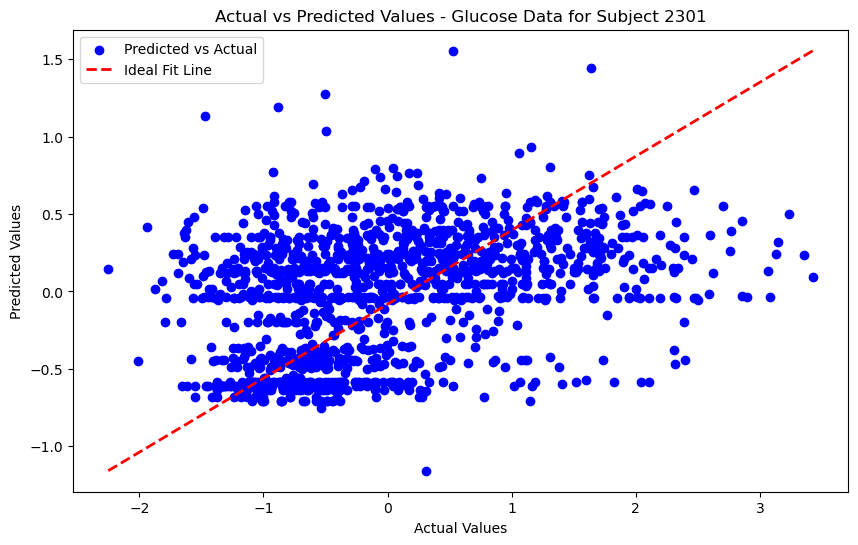

In [56]:
# Evaluate the model
mse = mean_squared_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_hat)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {np.sqrt(mse)}")
print(f"R-squared: {r2}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_hat, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_hat.min(), y_hat.max()], 'r--', lw=2, label='Ideal Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted Values - Glucose Data for Subject {subject_id}')
plt.legend()
plt.show()